Using GLMPPSeq to pull out temporal Sequences of spikes in the motor program 

In [32]:
import ppseq 
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 
import torch
from scipy import signal 
from scipy.signal import find_peaks
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from ppseq.plotting import plot_model,color_plot 
from ppseq.model import GLMPPSeq , PPSeq 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


Okay they pull spike times and put it into the data tensor of nneuons x timebins, with zeros and ones so like we are fine

Load in One of the datasets and process 

In [2]:
data_path = '/home/doshna/Desktop/Vahid_MP'
moth = '2024_11_08'
muscle_names = ['lax','lba','lsa','ldvm','ldlm','rdlm','rdvm','rsa','rba','rax']
ft_names = ['fx','fy','fz','tx','ty','tz']
low = pd.read_csv(f'{data_path}/{moth}_LOW.csv')
low_spikes = torch.tensor(
    low[muscle_names].to_numpy().T,
    dtype=torch.float32,device=device)
high = pd.read_csv(f'{data_path}/{moth}_HIGH.csv')
high_spikes = torch.tensor(
    high[muscle_names].to_numpy().T,
    dtype=torch.float32,device=device
)

In [8]:
all_spikes = torch.tensor(np.concatenate([low[muscle_names].to_numpy().T,high[muscle_names].to_numpy().T],1),dtype=torch.float32,device=device)

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:05&lt;00:00]</div>

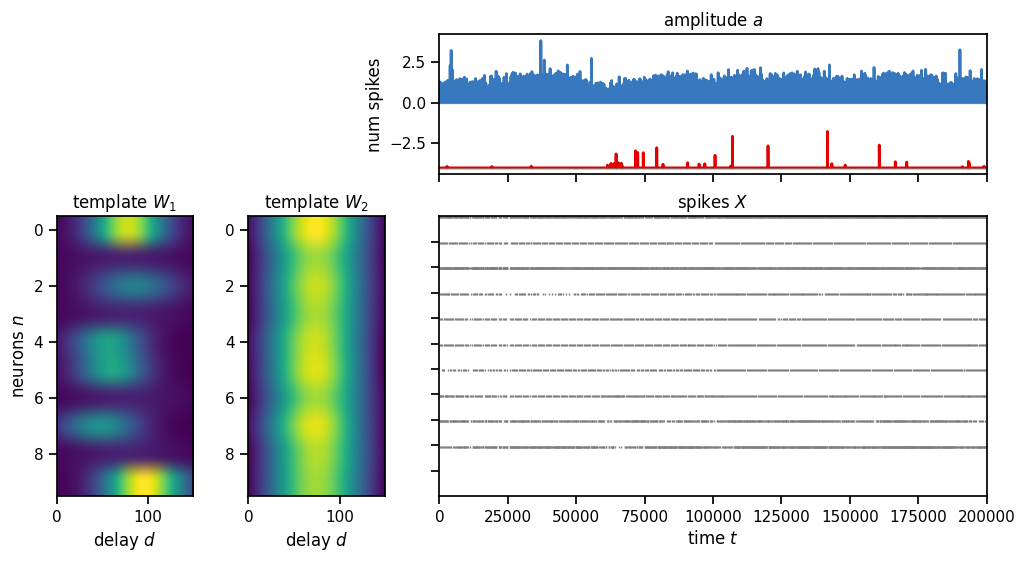

In [143]:
model_low =GLMPPSeq(
    num_templates=3,
    num_neurons=10,
    template_duration=150,
    n_covariates=3,
    rbf_width= 40, 
    # regularization
    l1=0.005,        # participation sparsity
    l1_amp=0.001,    # amplitude sparsity

    # priors on amplitude / timing latents
    alpha_a0=1.0,
    beta_a0=1.0,
    alpha_b0=1.0,
    beta_b0=1.0,
    alpha_t0=1.0,
    beta_t0=1.0, )
model_high = GLMPPSeq(
    num_templates=3,
    num_neurons=10,
    template_duration=150,
    n_covariates=3,
    rbf_width= 0.6, 
    # regularization
    l1=0.005,        # participation sparsity
    l1_amp=0.001,    # amplitude sparsity

    # priors on amplitude / timing latents
    alpha_a0=1.0,
    beta_a0=1.0,
    alpha_b0=1.0,
    beta_b0=1.0,
    alpha_t0=1.0,
    beta_t0=1.0,
)
# lps_low, amps_low = model_low.fit(
#     low_spikes,
#     num_iter=100
# )
# lps_high, amps_high = model_high.fit(
#     high_spikes,
#     num_iter=100
# )
model_all = GLMPPSeq(
    num_templates=2,
    num_neurons=10,
    template_duration=150,
    n_covariates=3,
    rbf_width= 0.6, 
    # regularization
    l1=0.005,        # participation sparsity
    l1_amp=0.001,    # amplitude sparsity

    # priors on amplitude / timing latents
    alpha_a0=1.0,
    beta_a0=1.0,
    alpha_b0=1.0,
    beta_b0=1.0,
    alpha_t0=1.0,
    beta_t0=1.0,
)
lps_all,amps_all = model_all.fit(all_spikes,num_iter=100)
plot_model(model_all.templates.cpu(),
           amps_all.cpu(),
           all_spikes.cpu(),
           spc=.33)

Mean is 0.008089523762464523 for low and 0.010196343064308167 for high


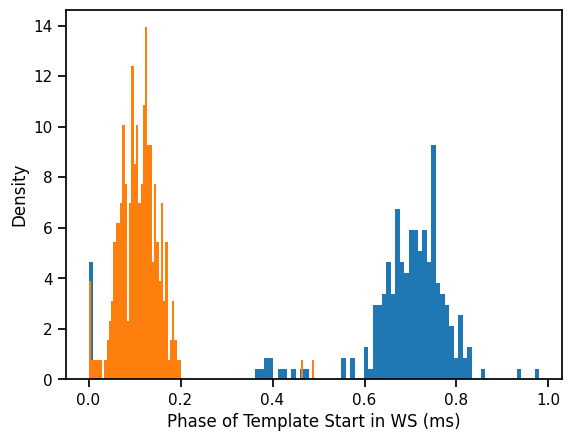

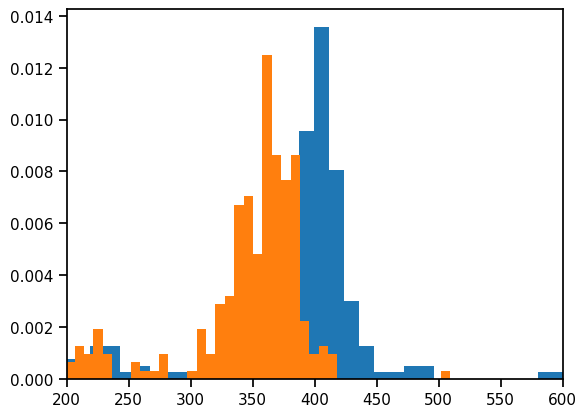

By this Pattern wbf is 27.167735188469056 for low and 30.73882972883961 for high
Variance of ws phases low 0.03149424406374025, 0.0026435667225877847 for high


In [161]:
at = amps_all.cpu()[0,:]
print(f"Mean is {at[:100000].mean()} for low and {at[100000:].mean()} for high")
lt = at[:100000]
ht = at[100000:]
peak_times_l = find_peaks(lt)[0]
peak_times_h = find_peaks(ht)[0]

low_amps= pd.DataFrame({'stim':low["stim"],'wb':low['wb'],'amp':lt})
high_amps= pd.DataFrame({'stim':high["stim"],'wb':high['wb'],'amp':ht})

mean_stim = low_amps.groupby('wb')['stim'].mean()
max_amp_idx_local = low_amps.groupby('wb')['amp'].apply(lambda x: x.reset_index(drop=True).idxmax()/x.shape[0])
la = pd.DataFrame({
    'stim': mean_stim,
    'amp_time': max_amp_idx_local
}).reset_index()

mean_stim = high_amps.groupby('wb')['stim'].mean()
max_amp_idx_local = high_amps.groupby('wb')['amp'].apply(lambda x: x.reset_index(drop=True).idxmax()/x.shape[0])
ha = pd.DataFrame({
    'stim': mean_stim,
    'amp_time': max_amp_idx_local 
}).reset_index()
# la['amp_time'] = [i if i <0.5 else i - 1 for i in la['amp_time']]
# ha['amp_time']   = [i if i < 0.5 else i -1 for i in ha['amp_time']]
plt.hist(la['amp_time'],bins=100,density=True)
plt.hist(ha['amp_time'],bins=100,density=True)
plt.xlabel("Phase of Template Start in WS (ms)")
plt.ylabel("Density")
plt.show()
plt.hist(np.diff(peak_times_l),bins=100,density=True)
plt.hist(np.diff(peak_times_h),bins=100,density=True)
plt.xlim(200,600)
plt.show()

offs_l = np.diff(peak_times_l)
offs_l = offs_l[offs_l > 100]

offs_l = offs_l[offs_l <600]
offs_h = np.diff(peak_times_h)
offs_h = offs_h[offs_h > 100]
offs_h = offs_h[offs_h <600]

print(f"By this Pattern wbf is {1e4 / (offs_l.mean())} for low and {1e4/(offs_h.mean())} for high")
print(f"Variance of ws phases low {np.var(la['amp_time'])}, {np.var(ha['amp_time'])} for high")

array([ 0.e+00,  1.e-09,  2.e-09, ..., -3.e-09, -2.e-09, -1.e-09],
      shape=(100000,))

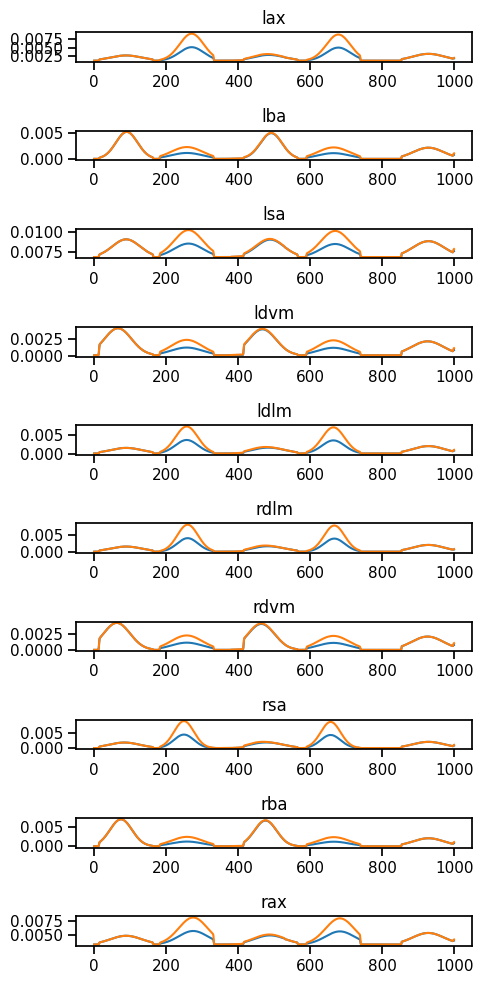

In [55]:
X = model_low.create_smooth_covariates()

if model_low.use_bias:
    T = X.shape[1]
    X = torch.cat([torch.ones(1, T, device=X.device), X], dim=0)
amps_fake = amps_low.cpu().numpy().copy()
amps_fake[0,:] = amps_fake[0,:] * 2
ratesfake = model_low.reconstruct(torch.tensor(amps_fake, device = device), X)
rates = model_low.reconstruct(amps_low,X)
f = plt.figure(figsize=(5,10))
for i in range(10):
    ax = f.add_subplot(10,1,i+1)
    ax.set_title(muscle_names[i])
    plt.plot(rates.cpu().T[:1000,i])
    plt.plot(ratesfake.cpu().T[:1000,i])
plt.tight_layout()

In [46]:
amps_fake.shape

(3, 100000)

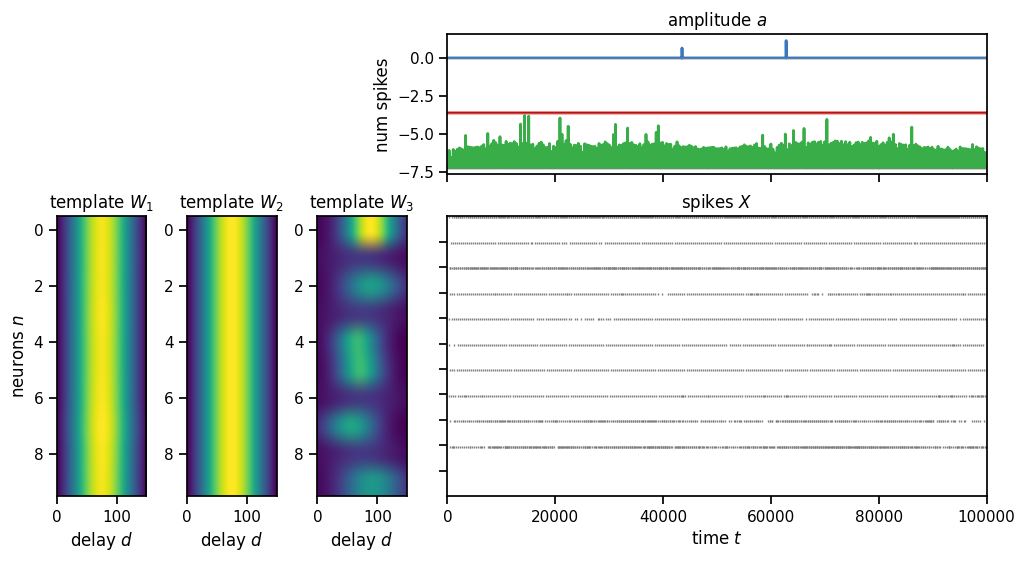

In [223]:
plot_model(model_high.templates.cpu(),
           amps_high.cpu(),
           high_spikes.cpu(),
           spc=.33)

Text(0.5, 0.98, 'Low vs High Condition: Amplitude and Stimulus (Top) | Templates (Bottom)')

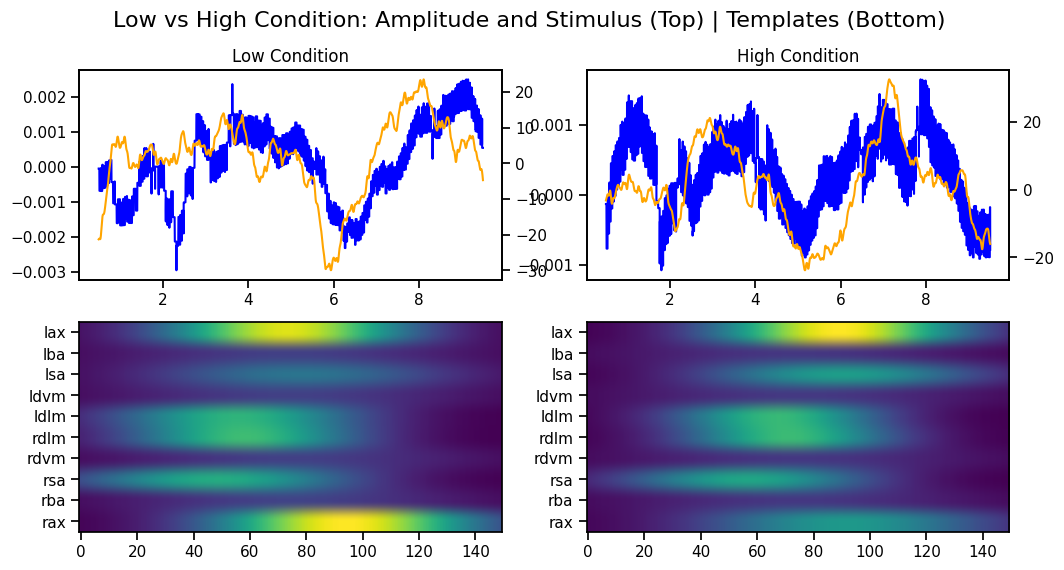

In [226]:
window_size = 5000
t = np.arange(0,10,1/10000)
moving_avg = np.convolve(amps_low.cpu()[1,:], np.ones(window_size)/window_size, mode='same')
ma_high = np.convolve(amps_high.cpu()[2,:], np.ones(window_size)/window_size, mode='same')
flower = low["stim"].to_numpy() 
flower = (flower - np.mean(flower)) * -0.14
flower_high = high["stim"].to_numpy() 
flower_high = (flower_high - np.mean(flower_high)) * 0.14
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(221)
ax.plot(t[5000:-5000],(moving_avg - np.mean(moving_avg))[5000:-5000],color='blue')
ax2 = ax.twinx()
ax.set_title('Low Condition')
ax2.plot(t[5000:-5000],flower[5000:-5000],color='orange')
ax3 = fig.add_subplot(222)
ax3.plot(t[5000:-5000],(ma_high - np.mean(ma_high))[5000:-5000],color='blue')
ax4 = ax3.twinx()
ax3.set_title('High Condition')
ax4.plot(t[5000:-5000], flower_high[5000:-5000],color='orange')
ax5 = fig.add_subplot(223)
ax5.imshow(model_low.templates.cpu()[1], aspect='auto', cmap='viridis')
ax5.set_yticks(range(10))
ax5.set_yticklabels(muscle_names)
ax6 = fig.add_subplot(224)
ax6.imshow(model_high.templates.cpu()[2], aspect='auto', cmap='viridis')
ax6.set_yticks(range(10))
ax6.set_yticklabels(muscle_names)
fig.suptitle('Low vs High Condition: Amplitude and Stimulus (Top) | Templates (Bottom)', fontsize=16)

In [45]:
temp_low = model_low.templates.cpu()[1].numpy().T 
# temp_high = model_high.templates.cpu()[0].numpy().T
max_low = temp_low.max()
# max_high = temp_high.max()
# max_val = max(max_low, max_high)

low_ldlm = temp_low[:,4]
ldlm_peak = np.argmax(low_ldlm)
# high_ldlm = temp_high[:,4]
# ldlm_peak_high = np.argmax(high_ldlm)


rv = np.arange(0, 100)
low_t = np.tile(rv, (10, 1)).T
high_t = np.tile(rv,(10,1)).T
for i in range(10):
    low_t[:,i] -= ldlm_peak 
    # high_t[:,i] -= ldlm_peak_high


In [28]:
temp_low

array([[8.472379e-05, 8.472379e-05, 8.472379e-05, ..., 8.472379e-05,
        8.472377e-05, 8.472379e-05],
       [8.599777e-05, 8.599777e-05, 8.599777e-05, ..., 8.599777e-05,
        8.599776e-05, 8.599777e-05],
       [8.728438e-05, 8.728438e-05, 8.728438e-05, ..., 8.728438e-05,
        8.728436e-05, 8.728438e-05],
       ...,
       [8.728438e-05, 8.728438e-05, 8.728438e-05, ..., 8.728438e-05,
        8.728436e-05, 8.728438e-05],
       [8.599777e-05, 8.599777e-05, 8.599777e-05, ..., 8.599777e-05,
        8.599776e-05, 8.599777e-05],
       [8.472379e-05, 8.472379e-05, 8.472379e-05, ..., 8.472379e-05,
        8.472377e-05, 8.472379e-05]], shape=(400, 10), dtype=float32)

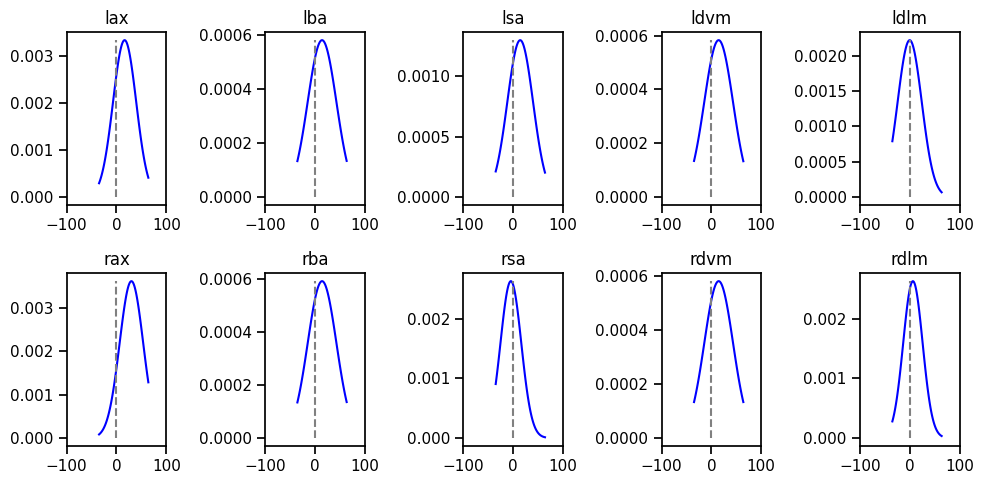

In [ ]:
fig = plt.figure(figsize=(10,5))
display_order = [0,1,2,3,4, 9,8,7,6,5]

for i,d in enumerate(muscle_names):
        if i <5:
            ax = fig.add_subplot(2,5,i+1)
            ax.plot(low_t[:,i],temp_low[:,i],color='blue')
            # ax.plot(high_t[:,i],temp_high[:,i] / max_val,color='red')
            ax.set_title(d)
            # ax.set_ylim(0,1.1)
            ax.set_xlim(-100,100)
            ax.vlines(0,0,temp_low[:,i].max(),color='gray',linestyle='--')
        else:
            ax = fig.add_subplot(2,5,10-(i-5))
            ax.plot(low_t[:,i],temp_low[:,i] ,color='blue')
            # ax.plot(high_t[:,i],temp_high[:,i] / max_val,color='red')
            ax.set_title(d)
            # ax.set_ylim(0,1.1)
            ax.set_xlim(-100,100)
            plt.vlines(0,0,temp_low[:,i].max(),color='gray',linestyle='-
        beta_b0=1.0,-')
        
fig.tight_layout()


In [6]:
xl = moving_avg[5000:-5000] - np.mean(moving_avg[5000:-5000])
yl = flower[5000:-5000] - np.mean(flower[5000:-5000])
xh = ma_high[5000:-5000] - np.mean(ma_high[5000:-5000])
yh = flower_high[5000:-5000] - np.mean(flower_high[5000:-5000])

ccl = np.correlate(xl, yl, mode='full')
lags = signal.correlation_lags(len(xl), len(yl), mode="full")

cch = np.correlate(xh, yh, mode='full')
lagsh = signal.correlation_lags(len(xh), len(yh), mode="full")

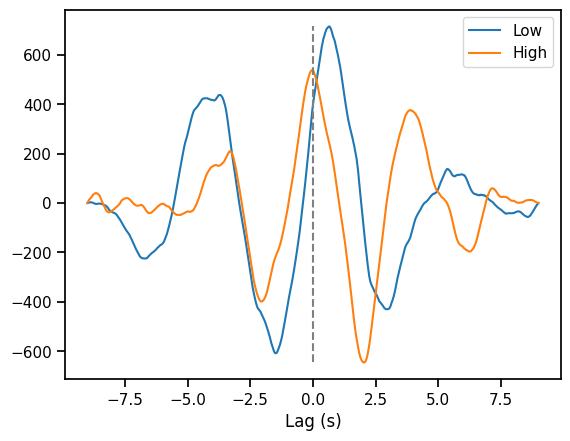

In [7]:
plt.plot(lags / 10000,ccl,label='Low')
plt.plot(lagsh / 10000,cch,label='High')
plt.vlines(0, ymin=min(ccl.min(), cch.min()), ymax=max(ccl.max(), cch.max()), color='gray', linestyle='--')
plt.xlabel('Lag (s)')
plt.legend()
plt.show()

In [24]:
amps_low.shape

torch.Size([3, 100000])

Okay Lets Run 100 random inits of the model and see what is consistent 

In [ ]:
amps_low_all = np.zeros((100,3,100000))
amps_high_all = np.zeros((100,3,100000))
temps_low = np.zeros((100,3,10,150))
temps_high = np.zeros((100,3,10,150))
for i in range(100):
    model_low = GLMPPSeq(
        num_templates=3,
        num_neurons=10,
        template_duration=150,
        n_covariates=3,
        rbf_width= 40, 
        # regularization
        l1=0.005,        # participation sparsity
        beta_b0=1.0,
        l1_amp=0.001,    # amplitude sparsity

        # priors on amplitude / timing latents
        alpha_a0=1.0,
        beta_a0=1.0,
        alpha_b0=1.0,
        beta_b0=1.0,
        alpha_t0=1.0,
        beta_t0=1.0, )

    model_high = GLMPPSeq(
        num_templates=3,
        num_neurons=10,
        template_duration=150,
        n_covariates=3,
        rbf_width= 40, 
        # regularization
        l1=0.005,        # participation sparsity
        l1_amp=0.001,    # amplitude sparsity

        # priors on amplitude / timing latents
        alpha_a0=1.0,
        beta_a0=1.0,
        alpha_b0=1.0,
        beta_b0=1.0,
        alpha_t0=1.0,
        beta_t0=1.0, )
    
    lps_low, amps_low = model_low.fit(
        low_spikes,
        num_iter=100
    )
    lps_high, amps_high = model_high.fit(
        high_spikes,
        num_iter=100
    )


    temp_low = model_low.templates.cpu().numpy()
    temp_high = model_high.templates.cpu().numpy()

    temps_low[i,:,:,:] = temp_low
    temps_high[i,:,:,:] = temp_high

    amps_low_all[i,:,:] = amps_low.cpu().numpy()
    amps_high_all[i,:,:] = amps_high.cpu().numpy()

np.savez('glmppseq_2024_11_08.npz', temps_low=temps_low,temps_high=temps_high,amps_low=amps_low_all,amps_high= amps_high_all)

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

...

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

In [4]:
dat = np.load("glmppseq_2024_11_08.npz")
temps_low = dat["temps_low"]
temps_high = dat["temps_high"]
amps_low_all = dat["amps_low"]
amps_high_all = dat["amps_high"]

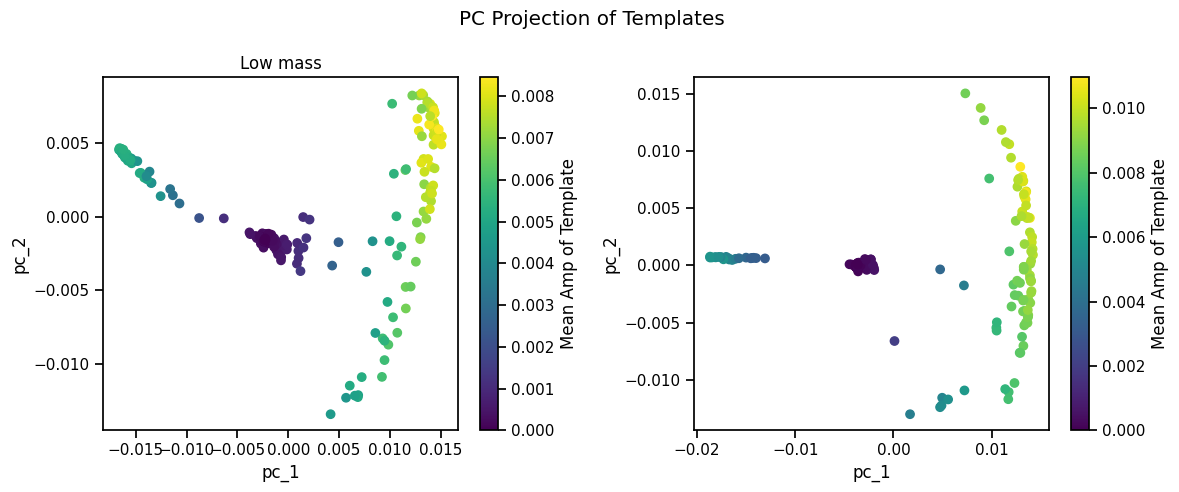

In [5]:
tl_flat = temps_low.reshape(300,10,150).reshape(300,-1)
amps = np.mean(amps_low_all,2).reshape(300,-1) 
mod_low = PCA(n_components=0.9)
pc_low = mod_low.fit_transform(tl_flat)

th_flat = temps_high.reshape(300,10,150).reshape(300,-1)
ampsg = np.mean(amps_high_all,2).reshape(300,-1) 
mod_high = PCA(n_components=0.9)
pc_high = mod_high.fit_transform(th_flat)

fig = plt.figure(figsize=(12,5)) 
fig.suptitle('PC Projection of Templates')

ax = fig.add_subplot(121)
ax.set_title('Low mass')
ax.set_xlabel('pc_1')
ax.set_ylabel('pc_2')
cax = ax.scatter(pc_low[:,0],pc_low[:,1],c=amps)
fig.colorbar(cax,ax=ax,label='Mean Amp of Template')
ax = fig.add_subplot(122)
ax.set_title=('High Mass')
ax.set_xlabel('pc_1')
ax.set_ylabel('pc_2')
cax = ax.scatter(pc_high[:,0],pc_high[:,1],c=ampsg)
fig.colorbar(cax,ax=ax,label='Mean Amp of Template')
fig.tight_layout()

In [6]:
ampsl = np.mean(amps_low_all,2) > 0.002
idx_grid_low = np.indices(amps_low_all.shape[:2])
meta_low = idx_grid_low[:,ampsl].T
tl_use = temps_low[ampsl]
ampsh = np.mean(amps_high_all,2)>0.002
th_use = temps_high[ampsh]
idx_grid_high = np.indices(amps_high_all.shape[:2])
meta_high = idx_grid_high[:,ampsh].T

In [7]:
amps_high_all[meta_high[12][0],meta_high[12][1]]

array([0., 0., 0., ..., 0., 0., 0.], shape=(100000,))

/tmp/ipykernel_100211/510569360.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


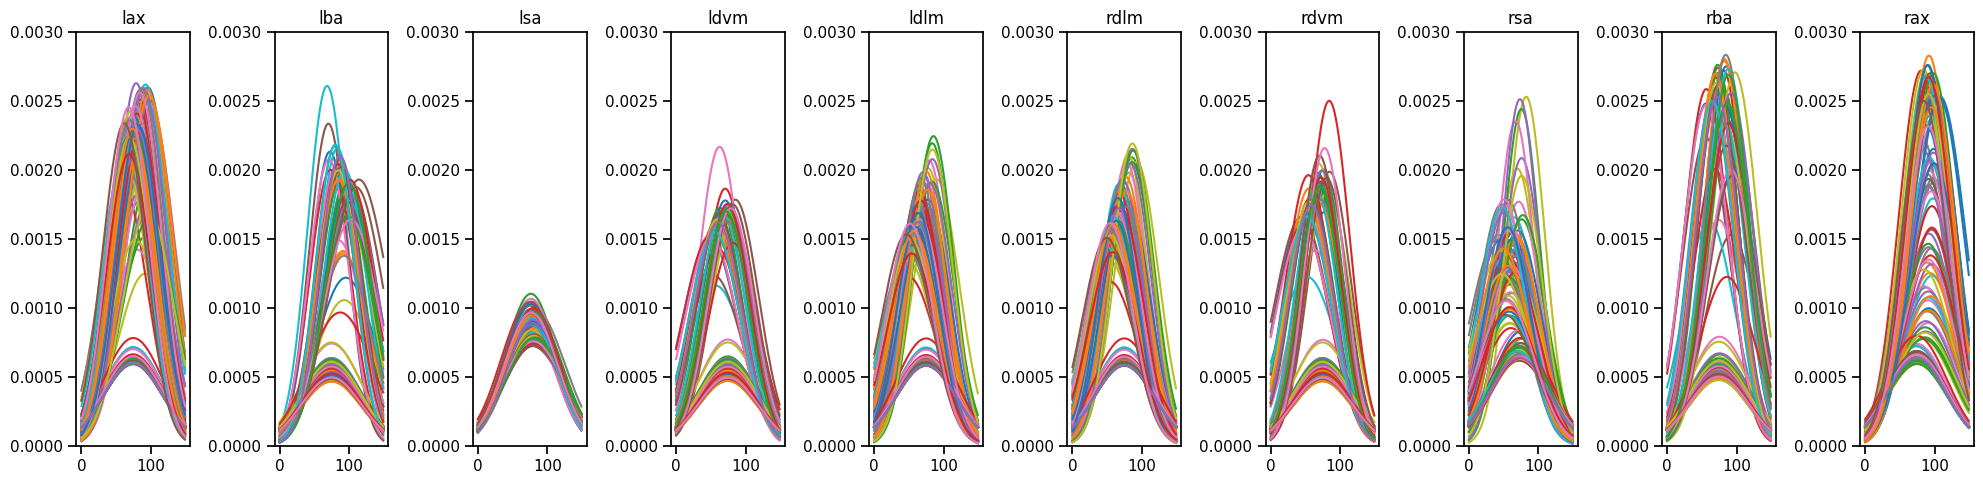

In [8]:
fig = plt.figure(figsize=(20,5))
for i in range(10):
    ax = fig.add_subplot(1,10,i+1)
    ax.set_title(muscle_names[i])
    ax.set_ylim(0,0.003)
    for j in range(tl_use.shape[0]):
        ax.plot(tl_use[j,i,:])

fig.tight_layout()
fig.show()


Okay Now we have the useable templates, lets compress down to the time of each peak (relative to Ldlm) and the intensity 

In [8]:
time_low = (np.argmax(tl_use,2))
max_low = np.max(tl_use,2)
time_high = (np.argmax(th_use,2))
max_high = np.max(th_use,2)

# Put times into ms 
time_low = (time_low - time_low[:,4,None])/10
time_high = (time_high - time_high[:,4,None])/10

# Concat and zscore times and maxes seperate for the pca 
forpc_low = np.concatenate([(time_low-time_low.mean())/time_low.std(),(max_low - max_low.mean())/max_low.std()],axis=1)
forpc_high = np.concatenate([(time_high-time_high.mean())/time_high.std(),(max_high - max_high.mean())/max_high.std()],axis=1)



Text(0.5, 1.0, 'Pc Projection of Tempaltes')

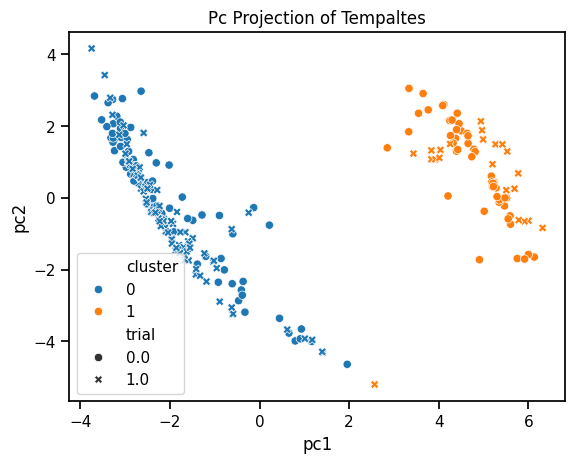

In [9]:
import seaborn as sns
mod = PCA(n_components=0.9)
pc = mod.fit_transform(np.concatenate([forpc_low,forpc_high]))
km = KMeans(n_clusters=2,n_init="auto").fit(pc)

trials = np.zeros(len(forpc_low)+len(forpc_high))
trials[len(forpc_low):] = 1


pcdf = pd.DataFrame({'pc1':pc[:,0],'pc2':pc[:,1],'trial':trials,'cluster':km.labels_})

p = sns.scatterplot(data=pcdf,x='pc1',y='pc2',style='trial',hue='cluster')
p.set_title('Pc Projection of Tempaltes')


In [10]:
# Split The low and high into Each of the clusters 

tl_0 = tl_use[km.labels_[:tl_use.shape[0]].astype(bool)]
tl_1 = tl_use[(1-km.labels_[:tl_use.shape[0]]).astype(bool)]

th_0 = th_use[km.labels_[tl_use.shape[0]:].astype(bool)]
th_1 = th_use[(1-km.labels_[tl_use.shape[0]:]).astype(bool)]

tl_0.mean(0)[0,:].shape

(150,)

/tmp/ipykernel_102574/2604608386.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


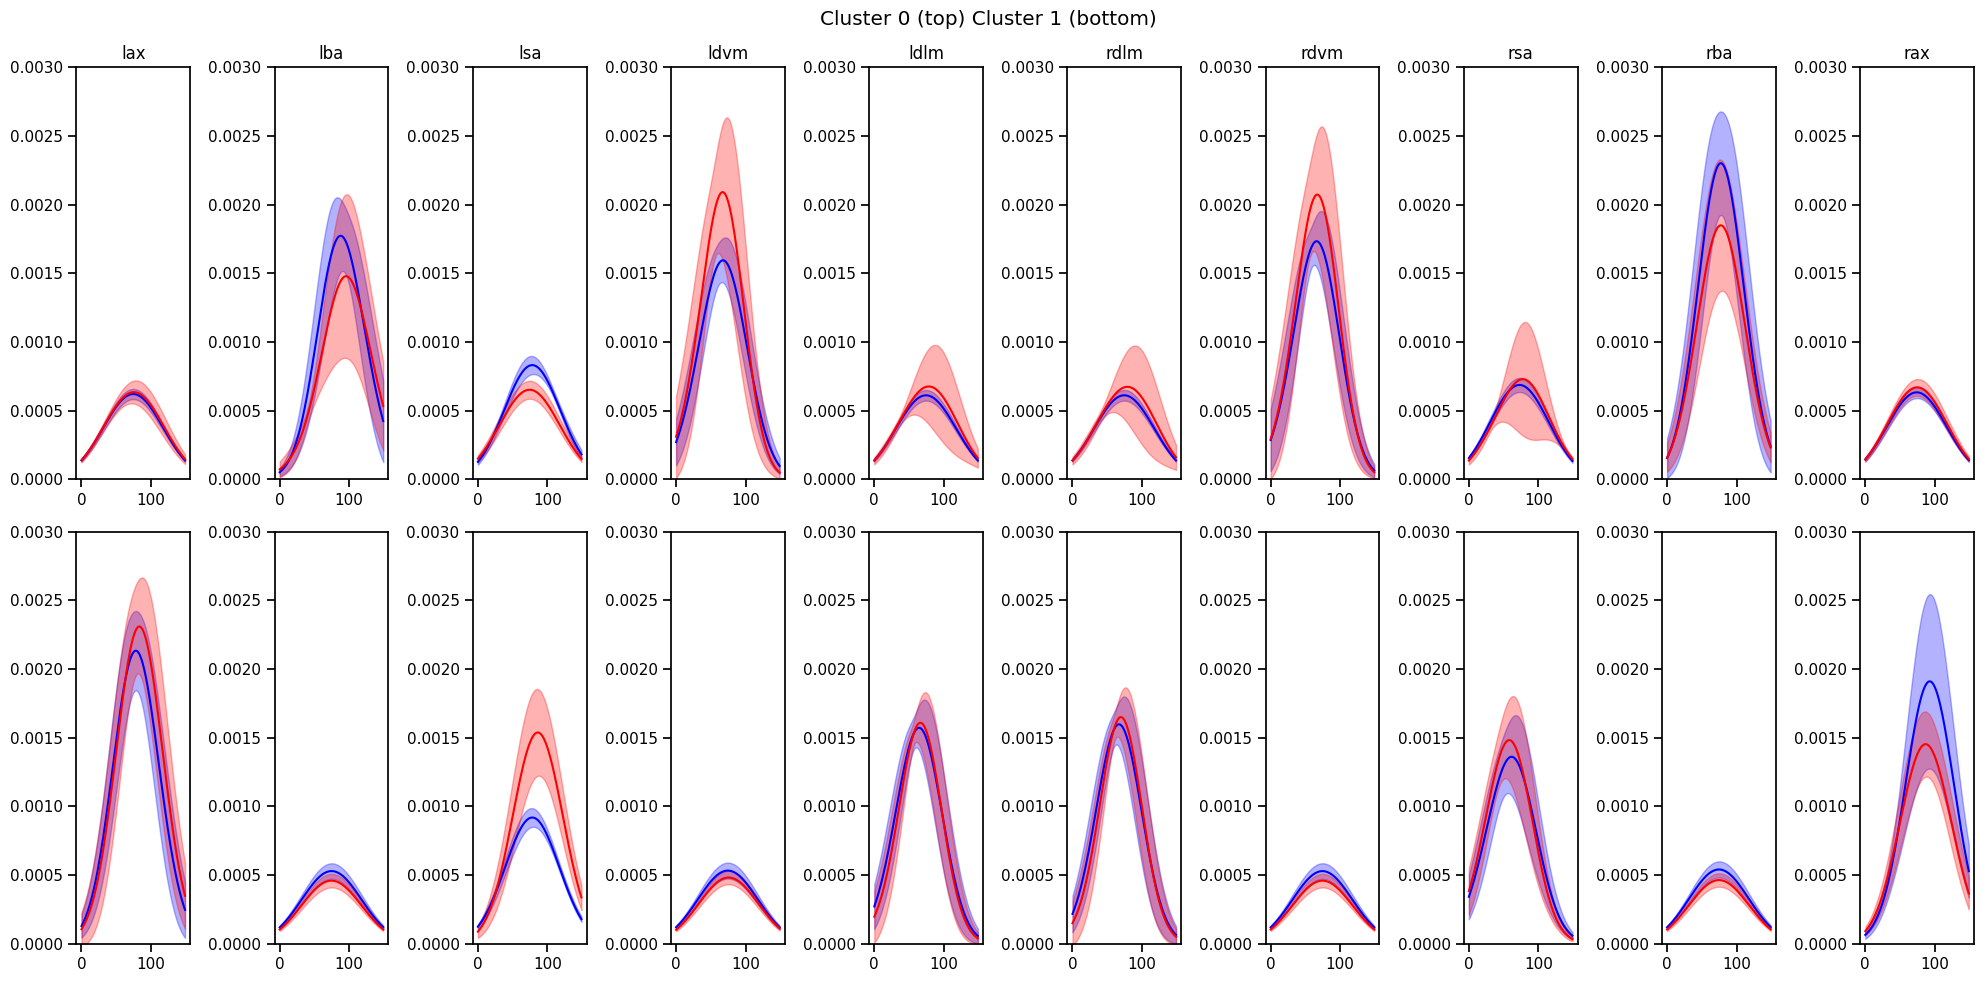

In [11]:
fig = plt.figure(figsize=(20,10))
fig.suptitle("Cluster 0 (top) Cluster 1 (bottom) ")
for i in range(10):
    ax = fig.add_subplot(2,10,i+1)
    ax.set_title(muscle_names[i])
    ax.set_ylim(0,0.003)
    lm0 = tl_0.mean(0)[i,:]
    lsem0 = tl_0.std(0)[i,:] 

    hm0 = th_0.mean(0)[i,:]
    hsem0 = th_0.std(0)[i,:]
    plt.plot(lm0,color='b')
    plt.fill_between(np.arange(150),lm0-lsem0,lm0+lsem0,alpha=0.3,color='b')
    plt.plot(th_0.mean(0)[i,:],color='r')
    plt.fill_between(np.arange(150),hm0-hsem0,hm0+hsem0,alpha=0.3,color='r')
for i in range(10):
    ax = fig.add_subplot(2,10,i+11)
    ax.set_ylim(0,0.003)
    
    lm1 = tl_1.mean(0)[i,:]
    lsem1 = tl_1.std(0)[i,:] 

    hm1 = th_1.mean(0)[i,:]
    hsem1 = th_1.std(0)[i,:]
    plt.plot(lm1,color='b')
    plt.fill_between(np.arange(150),lm1-lsem1,lm1+lsem1,alpha=0.3,color='b')
    plt.plot(th_1.mean(0)[i,:],color='r')
    plt.fill_between(np.arange(150),hm1-hsem1,hm1+hsem1,alpha=0.3,color='r')

fig.tight_layout()
fig.show()


So Within Clusters they aren't chanign from low to high but what about percentage of templates in that cluster? 

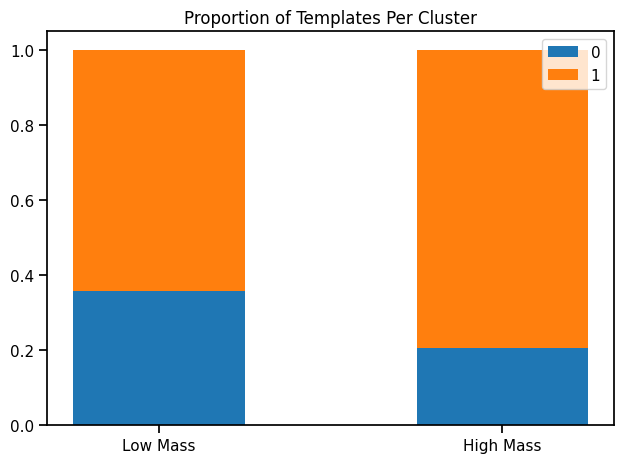

In [12]:
pct_0_low = tl_0.shape[0] / tl_use.shape[0]
pct_0_high = th_0.shape[0] / th_use.shape[0]
pct_1_low = 1-pct_0_low
pct_1_high = 1-pct_0_high

Conditions = (
    "Low Mass","High Mass"
)
pcts = {
    "0": np.array([pct_0_low,pct_0_high]),
    "1": np.array([pct_1_low,pct_1_high]),
}
width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(2)

for boolean, pct in pcts.items():
    p = ax.bar(Conditions, pct, width, label=boolean, bottom=bottom)
    bottom += pct

ax.set_title("Proportion of Templates Per Cluster")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

0 seems to be the dominate cluster, also has dlm,ax,sa which feels right. How do the amplitude traces look for low vs high with this tempalte?

In [13]:
low_0_idx = km.labels_[:tl_use.shape[0]].astype(bool)
high_0_idx = km.labels_[tl_use.shape[0]:].astype(bool)
low_0_amps_idx = meta_low[low_0_idx]
high_0_amps_idx = meta_high[high_0_idx]

low_1_idx = (1-km.labels_[:tl_use.shape[0]]).astype(bool)
high_1_idx = (1-km.labels_[tl_use.shape[0]:]).astype(bool)
low_1_amps_idx = meta_low[low_1_idx]
high_1_amps_idx = meta_high[high_1_idx]

print(f"Template 0 Gets Pulled out {low_0_amps_idx.shape[0]} Percent of the Time In Low ")
print(f"Template 0 Gets Pulled out {high_0_amps_idx.shape[0]} Percent of the Time In High")

Template 0 Gets Pulled out 49 Percent of the Time In Low 
Template 0 Gets Pulled out 22 Percent of the Time In High


In [14]:
amps_0_low = amps_low_all[low_0_amps_idx[:,0],low_0_amps_idx[:,1]]
amps_0_high = amps_high_all[high_0_amps_idx[:,0],high_0_amps_idx[:,1]]

a0low = pd.DataFrame(amps_0_low.T)
a0low["wb"] = low["wb"]
a0low_means = a0low.groupby('wb').mean().values.T

a0high = pd.DataFrame(amps_0_high.T)
a0high["wb"] = high["wb"]
a0high_means = a0high.groupby('wb').mean().values.T

amps_1_low = amps_low_all[low_1_amps_idx[:,0],low_1_amps_idx[:,1]]
amps_1_high = amps_high_all[high_1_amps_idx[:,0],high_1_amps_idx[:,1]]

a1low = pd.DataFrame(amps_1_low.T)
a1low["wb"] = low["wb"]
a1low_means = a1low.groupby('wb').mean().values.T

a1high = pd.DataFrame(amps_1_high.T)
a1high["wb"] = high["wb"]
a1high_means = a1high.groupby('wb').mean().values.T

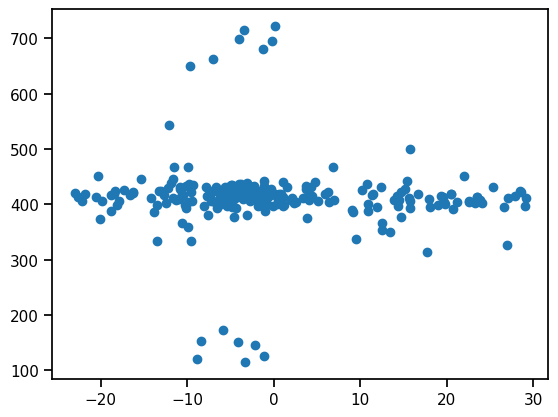

In [ ]:
from scipy.signal import find_peaks
fpre = low[['wb','stim']].groupby('wb').mean()
fpost = high[['wb','stim']].groupby('wb').mean()
a1low_times = a1low.groupby('wb').idxmax().diff()

# plt.scatter(0.14*(fpre['stim'] - fpre['stim'].values.mean()),a1low_times.values.mean(1))
# plt.scatter(0.14*(fpost['stim'] - fpost['stim'].values.mean()),a1high_times.values.mean(1))

In [58]:
peaks_a1low = []
for row in a1low.drop(columns="wb").values.T:
    peaks, _ = find_peaks(row)
    peaks_a1low.append(peaks)


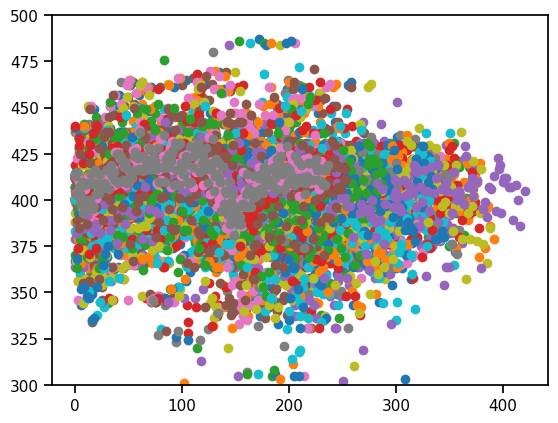

In [65]:
for p in peaks_a1low:
    plt.scatter(range(len(p)-1),np.diff(p))
plt.ylim(300,500)
plt.show()

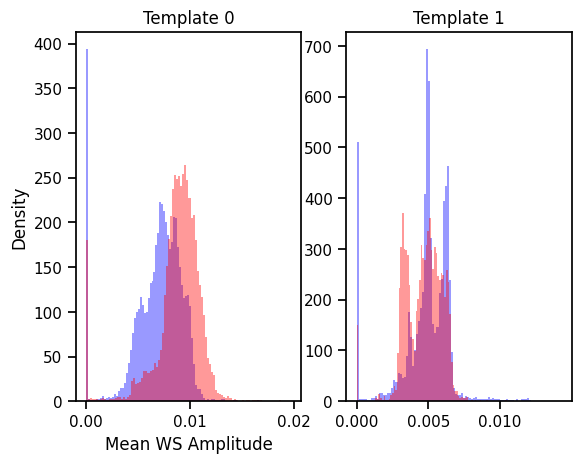

In [26]:
fig = plt.figure() 
ax = fig.add_subplot(121)
ax.set_title('Template 0')
ax.set_xlabel('Mean WS Amplitude')
ax.set_ylabel('Density')
ax.hist(a0low_means.reshape(-1),color="b",bins=100,alpha=0.4,density=True)
ax.hist(a0high_means.reshape(-1),color='r',bins=100,alpha=0.4,density=True)
ax2 = fig.add_subplot(122)
ax2.set_title('Template 1')
ax.set_xlabel('Mean WS Amplitude')
ax.set_ylabel('Density')
ax2.hist(a1low_means.reshape(-1),color="b",bins=100,alpha=0.4,density=True)
ax2.hist(a1high_means.reshape(-1),color='r',bins=100,alpha=0.4,density=True)
plt.show()